# Единый датасет для модулей 1-4

- загружаю все 4 файла `stats__module_1.csv` ... `stats__module_4.csv`;
- сначала очищаю данные: удаляю строки без `user_id` и/или `course_id`;
- отдельно исследую дубли в `module 1` и удаляю их;
- только после очистки и удаления дублей привожу таблицы к единой схеме колонок;
- один раз собираю общий датафрейм по всем модулям;
- считаю эвристики только для модулей 1-3;
- модуль 4 использую только в объединении, очистке и стандартизации, но не использую в эвристиках и не вычисляю для него статус;
- считаю корреляции только там, где есть реальный таргет, то есть на модулях 1 и 2.

In [137]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

NOTEBOOK_DIR = Path.cwd()
HACKATHON_DIR = NOTEBOOK_DIR.parent
SRC_DIR = HACKATHON_DIR / "src"

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("SRC_DIR:", SRC_DIR)
print("SRC_DIR exists:", SRC_DIR.exists())

NOTEBOOK_DIR: /Users/maria/Desktop/uni/hackathon/modules
SRC_DIR: /Users/maria/Desktop/uni/hackathon/src
SRC_DIR exists: True


## 1. Загрузка всех четырёх модулей

Сразу загружаю все 4 CSV и добавляю номер модуля.

In [138]:
raw_tables = {}

for module in [1, 2, 3, 4]:
    path = SRC_DIR / f"stats__module_{module}.csv"
    df = pd.read_csv(path).drop(columns=["Unnamed: 0"], errors="ignore").copy()
    df["module"] = module
    raw_tables[module] = df
    print(f"module {module}: shape={df.shape}")

raw_tables[1].head()

module 1: shape=(3261, 19)
module 2: shape=(1955, 20)
module 3: shape=(1785, 19)
module 4: shape=(1707, 18)


,user_id,Кружок,teacher_id,Дата зачисления,id параллели,Уровень,course_id,Просмотрел уроков,Просмотрено контента,Просмотрено 80% ур или видеоконт,Посетил урок в онлайне,Решено ИЗ,Решены все обяз.ИЗ,Пройден тек.контроль,Балл ПА,Сдал ПА,Дата сдачи ПА (МСК),Статус,module
0,701741.0,Python. Начальный уровень. Онлайн. 1 модуль,699869.0,2025-09-19,1149.0,Начальный,1029.0,20,100.000000,Да,Нет,60,Да,Да,15.0,Да,2025-12-05,Завершил,1
1,737977.0,Python. Начальный уровень. Онлайн. 1 модуль,730341.0,2025-11-05,1216.0,Начальный,1029.0,20,97.915459,Да,Да,60,Да,Да,14.0,Да,2025-11-29,Завершил,1
2,722851.0,Python. Базовый уровень. Онлайн. 1 модуль,730208.0,2025-10-21,1186.0,Базовый,1030.0,0,0.000000,Нет,Нет,0,Нет,Не сдавал,NaN,Не сдавал,NaN,Отчислен,1
3,709724.0,Python. Базовый уровень. Онлайн. 1 модуль,700089.0,2025-09-23,1108.0,Базовый,1030.0,20,99.160018,Да,Да,60,Да,Да,14.0,Да,2025-11-28,Завершил,1
4,717763.0,Python. Базовый уровень. Онлайн. 1 модуль,718519.0,2025-10-09,1055.0,Базовый,1030.0,0,0.000000,Нет,Нет,0,Нет,Не сдавал,NaN,Не сдавал,NaN,Отчислен,1


В модуле 1 есть единственный человек, который попытался сдать ПА, набрал 3.5 баллов и не сдал. Все остальные не сданные ПА - это люди, которые не предпринимали попытки сдать ПА.

## 2. Единая схема и названия колонок

Здесь фиксирую итоговую схему колонок. Все финальные названия в латинице, без пробелов и специальных символов.

### 2.1. Соответствие колонок между модулями

| Итоговая колонка | Модуль 1 | Модуль 2 | Модуль 3 | Модуль 4 | Комментарий |
|---|---|---|---|---|---|
| `module` | добавляется вручную | добавляется вручную | добавляется вручную | добавляется вручную | номер модуля |
| `user_id` | `user_id` | `user_id` | `user_id` | `user_id` | идентификатор |
| `club_name` | `Кружок` | `Кружок` | `Кружок` | `Кружок` | текстовое поле |
| `teacher_id` | `teacher_id` | `teacher_id` | `teacher_id` | `teacher_id` | идентификатор |
| `course_id` | `course_id` | `course_id` | `course_id` | `course_id` | идентификатор |
| `cohort_id` | `id параллели` | `id параллели` | `id параллели` | `id параллели` | идентификатор |
| `level_bin` | перекодируется из `Уровень` | перекодируется из `Уровень` | перекодируется из `Уровень` | перекодируется из `Уровень` | `Начальный -> 0`, `Базовый -> 1` |
| `enrollment_date` | `Дата зачисления` | отсутствует | отсутствует | отсутствует | дата |
| `lessons_watched_total` | `Просмотрел уроков` | `Смотрел уроков` | `Смотрел уроков` | `Смотрел уроков` | числовое поле |
| `lessons_watched_80_count` | отсутствует | `Посмотрел уроков на 80%` | `Посмотрел уроков на 80%` | `Посмотрел уроков на 80%` | числовое поле |
| `content_units_watched` | `Просмотрено контента` | `Просмотрено контента (ед)` | `Просмотрено контента (ед)` | `Просмотрено контента (ед)` | числовое поле |
| `view_criterion` | `Просмотрено 80% ур или видеоконт` | `Просмотрено 720ед видеоконт и 80% ур ` | `Просмотрено 720ед видеоконт и 80% ур ` | `Просмотрено 720ед видеоконт и 80% ур ` | бинарный флаг `0/1` |
| `webinar_attended` | `Посетил урок в онлайне` | `Посетил урок в онлайне` | `Посетил урок в онлайне` | `Посетил урок в онлайне` | бинарный флаг `0/1` |
| `solved_hw_count` | `Решено ИЗ` | `Решено ИЗ` | `Решено ИЗ` | `Решено ИЗ` | числовое поле |
| `required_hw_done` | `Решены все обяз.ИЗ` | `Решены все обяз.ИЗ` | `Решены все обяз.ИЗ` | `Решены все обяз.ИЗ` | бинарный флаг `0/1` |
| `current_control_passed` | `Пройден тек.контроль` | `Пройден тек.контроль` | `Пройден тек.контроль` | `Пройден тек.контроль` | бинарный флаг `0/1` |
| `reflection_passed` | отсутствует | `Пройдена рефлексия` | `Пройдена рефлексия` | `Пройдена рефлексия` | бинарный флаг `0/1` |
| `pa_score` | `Балл ПА` | `Балл ПА` | `Балл ПА` | отсутствует | числовое поле |
| `pa_passed` | `Сдал ПА` | `Сдал ПА` | `Сдал ПА` | `Сдал ПА` | бинарный флаг `0/1` |
| `pa_date_msk` | `Дата сдачи ПА (МСК)` | `Дата сдачи ПА (МСК)` | `Дата сдачи ПА (МСК)` | отсутствует | дата |
| `ia_passed` | отсутствует | отсутствует | отсутствует | `Сдал ИА` | бинарный флаг `0/1`, только для модуля 4 |
| `status_actual` | `Статус` | `Статус` | отсутствует | отсутствует | реальный таргет есть только у модулей 1-2 |

### 2.2. Пропуски и перекодировки

| Итоговая колонка | Работа с пропусками | Перекодировка |
|---|---|---|
| `module` | пропусков нет | целый номер модуля |
| `user_id` | сохраняется как есть | числовой идентификатор |
| `club_name` | сохраняется как есть | текст |
| `teacher_id` | сохраняется как есть | числовой идентификатор |
| `course_id` | сохраняется как есть | числовой идентификатор |
| `cohort_id` | сохраняется как есть | числовой идентификатор |
| `level_bin` | если `Уровень` отсутствует, остаётся `NaN` | `Начальный -> 0`, `Базовый -> 1` |
| `enrollment_date` | если исходной колонки нет, ставится `pd.NA` | сохраняется как дата/текст |
| `lessons_watched_total` | в текущих файлах после преобразования новых пропусков не появилось | `pd.to_numeric(..., errors="coerce")` |
| `lessons_watched_80_count` | если исходной колонки нет, ставится `pd.NA`; иначе в текущих файлах после преобразования новых пропусков не появилось | `pd.to_numeric(..., errors="coerce")` |
| `content_units_watched` | в текущих файлах после преобразования новых пропусков не появилось | `pd.to_numeric(..., errors="coerce")` |
| `view_criterion` | если исходной колонки нет, ставится `pd.NA` | сразу кодируется в `1`, если значение `Да`, иначе в `0` |
| `webinar_attended` | если исходной колонки нет, ставится `pd.NA` | сразу кодируется в `1`, если значение `Да`, иначе в `0` |
| `solved_hw_count` | в текущих файлах после преобразования новых пропусков не появилось | `pd.to_numeric(..., errors="coerce")` |
| `required_hw_done` | если исходной колонки нет, ставится `pd.NA` | сразу кодируется в `1`, если значение `Да`, иначе в `0` |
| `current_control_passed` | если исходной колонки нет, ставится `pd.NA` | сразу кодируется в `1`, если значение `Да`, иначе в `0` |
| `reflection_passed` | если исходной колонки нет, ставится `pd.NA` | сразу кодируется в `1`, если значение `Да`, иначе в `0` |
| `pa_score` | исходные пропуски сохраняются; новых пропусков после преобразования в текущих файлах не появилось | `pd.to_numeric(..., errors="coerce")` |
| `pa_passed` | если исходной колонки нет, ставится `pd.NA` | сразу кодируется в `1`, если значение `Да`, иначе в `0` |
| `pa_date_msk` | если исходной колонки нет, ставится `pd.NA` | сохраняется как дата/текст |
| `ia_passed` | если исходной колонки нет, ставится `pd.NA` | сразу кодируется в `1`, если значение `Да`, иначе в `0` |

In [139]:
def yes_to_bool(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    return numeric.eq(1) | series.fillna("").astype(str).str.strip().eq("Да")


def yes_to_int(series: pd.Series, preserve_na: bool = True) -> pd.Series:
    result = yes_to_bool(series).astype("Int64")
    if preserve_na:
        result = result.mask(series.isna(), pd.NA)
    return result


def standardize_module_table(df: pd.DataFrame, module: int) -> pd.DataFrame:
    result = df.copy()

    if "Просмотрено 80% ур или видеоконт" in result.columns:
        result["view_criterion"] = yes_to_int(result["Просмотрено 80% ур или видеоконт"])
    elif "Просмотрено 720ед видеоконт и 80% ур " in result.columns:
        result["view_criterion"] = yes_to_int(result["Просмотрено 720ед видеоконт и 80% ур "])
    else:
        result["view_criterion"] = pd.NA

    if "Просмотрено контента" in result.columns:
        result["content_units_watched"] = pd.to_numeric(result["Просмотрено контента"], errors="coerce")
    elif "Просмотрено контента (ед)" in result.columns:
        result["content_units_watched"] = pd.to_numeric(result["Просмотрено контента (ед)"], errors="coerce")
    else:
        result["content_units_watched"] = pd.NA

    if "Просмотрел уроков" in result.columns:
        result["lessons_watched_total"] = pd.to_numeric(result["Просмотрел уроков"], errors="coerce")
    elif "Смотрел уроков" in result.columns:
        result["lessons_watched_total"] = pd.to_numeric(result["Смотрел уроков"], errors="coerce")
    else:
        result["lessons_watched_total"] = pd.NA

    if "Посмотрел уроков на 80%" in result.columns:
        result["lessons_watched_80_count"] = pd.to_numeric(result["Посмотрел уроков на 80%"], errors="coerce")
    else:
        result["lessons_watched_80_count"] = pd.NA

    result["level_bin"] = result.get("Уровень", pd.Series(pd.NA, index=result.index)).map({"Начальный": 0, "Базовый": 1})
    result["solved_hw_count"] = pd.to_numeric(result.get("Решено ИЗ", pd.Series(pd.NA, index=result.index)), errors="coerce")
    result["pa_score"] = pd.to_numeric(result.get("Балл ПА", pd.Series(pd.NA, index=result.index)), errors="coerce")

    result["club_name"] = result.get("Кружок", pd.NA)
    result["cohort_id"] = result.get("id параллели", pd.NA)
    result["enrollment_date"] = result.get("Дата зачисления", pd.NA)
    result["webinar_attended"] = yes_to_int(result.get("Посетил урок в онлайне", pd.Series(pd.NA, index=result.index)))
    result["required_hw_done"] = yes_to_int(result.get("Решены все обяз.ИЗ", pd.Series(pd.NA, index=result.index)))
    result["current_control_passed"] = yes_to_int(result.get("Пройден тек.контроль", pd.Series(pd.NA, index=result.index)))
    result["reflection_passed"] = yes_to_int(result.get("Пройдена рефлексия", pd.Series(pd.NA, index=result.index)))
    result["pa_passed"] = yes_to_int(result.get("Сдал ПА", pd.Series(pd.NA, index=result.index)))
    result["pa_date_msk"] = result.get("Дата сдачи ПА (МСК)", pd.NA)
    result["ia_passed"] = yes_to_int(result.get("Сдал ИА", pd.Series(pd.NA, index=result.index)))
    result["status_actual"] = result.get("Статус", pd.NA)

    final_columns = [
        "module",
        "user_id",
        "club_name",
        "teacher_id",
        "course_id",
        "cohort_id",
        "level_bin",
        "enrollment_date",
        "lessons_watched_total",
        "lessons_watched_80_count",
        "content_units_watched",
        "view_criterion",
        "webinar_attended",
        "solved_hw_count",
        "required_hw_done",
        "current_control_passed",
        "reflection_passed",
        "pa_score",
        "pa_passed",
        "pa_date_msk",
        "ia_passed",
        "status_actual",
    ]

    return result[final_columns].copy()

## 3. Первичная очистка данных, удаление дублей и сборка единого датасета

Перед сборкой единого датасета сначала удаляю строки без `user_id` и/или `course_id`.

Это нужно сделать до всех дальнейших шагов, потому что:

1. строки без ключей нельзя корректно использовать в анализе на уровне `module + user_id + course_id`;
2. изучать дубли имеет смысл только на валидных записях;
3. единый датасет лучше собирать один раз, уже после очистки.

In [140]:
cleaned_raw_tables = {}
invalid_key_stats = []

for module, df in raw_tables.items():
    valid_mask = df["user_id"].notna() & df["course_id"].notna()
    cleaned_raw_tables[module] = df.loc[valid_mask].copy()
    invalid_key_stats.append(
        {
            "module": module,
            "rows_before_filter": len(df),
            "rows_removed_without_user_or_course": int((~valid_mask).sum()),
            "rows_after_filter": int(valid_mask.sum()),
        }
    )

print("Размеры таблиц после удаления строк без user_id и/или course_id:")
display(pd.DataFrame(invalid_key_stats))

Размеры таблиц после удаления строк без user_id и/или course_id:


,module,rows_before_filter,rows_removed_without_user_or_course,rows_after_filter
0,1,3261,61,3200
1,2,1955,0,1955
2,3,1785,0,1785
3,4,1707,18,1689


После удаления строк без `user_id` и/или `course_id` отдельно разбираю дубли в модуле 1.

В этом разделе проверяю три вещи:

1. Сколько дублей остаётся в модуле 1 после очистки ключей.
2. Отличаются ли эти дубли чем-то, кроме `teacher_id`.
3. Можно ли после проверки просто оставить по одной записи на пару `user_id + course_id`, а затем уже собирать единый датасет.

In [141]:
module1_valid_df = cleaned_raw_tables[1].drop(columns=["Unnamed: 0"], errors="ignore").copy()

duplicate_keys = ["user_id", "course_id"]
module1_duplicate_rows_df = module1_valid_df[
    module1_valid_df.duplicated(subset=duplicate_keys, keep=False)
].copy()
module1_duplicate_rows_df = module1_duplicate_rows_df.sort_values(["user_id", "course_id", "teacher_id"])

print("Строк в модуле 1 после удаления пустых user_id/course_id:", len(module1_valid_df))
print("Строк-дублей по паре user_id + course_id:", len(module1_duplicate_rows_df))
print("Количество групп дублей:", module1_duplicate_rows_df[duplicate_keys].drop_duplicates().shape[0])

display(module1_duplicate_rows_df.head(5))

Строк в модуле 1 после удаления пустых user_id/course_id: 3200
Строк-дублей по паре user_id + course_id: 420
Количество групп дублей: 192


,user_id,Кружок,teacher_id,Дата зачисления,id параллели,Уровень,course_id,Просмотрел уроков,Просмотрено контента,Просмотрено 80% ур или видеоконт,Посетил урок в онлайне,Решено ИЗ,Решены все обяз.ИЗ,Пройден тек.контроль,Балл ПА,Сдал ПА,Дата сдачи ПА (МСК),Статус,module
130,700083.0,Python. Начальный уровень. Онлайн. 1 модуль,718537.0,2025-09-19,1190.0,Начальный,1029.0,0,0.000000,Нет,Нет,0,Нет,Не сдавал,NaN,Не сдавал,NaN,Отчислен,1
129,700083.0,Python. Начальный уровень. Онлайн. 1 модуль,732430.0,2025-09-19,1190.0,Начальный,1029.0,0,0.000000,Нет,Нет,0,Нет,Не сдавал,NaN,Не сдавал,NaN,Отчислен,1
176,700342.0,Python. Начальный уровень. Онлайн. 1 модуль,699986.0,2025-10-13,1147.0,Начальный,1029.0,19,98.525253,Да,Да,60,Да,Да,12.0,Да,2025-11-30,Завершил,1
174,700342.0,Python. Начальный уровень. Онлайн. 1 модуль,700313.0,2025-10-13,1147.0,Начальный,1029.0,19,98.525253,Да,Да,60,Да,Да,12.0,Да,2025-11-30,Завершил,1
175,700342.0,Python. Начальный уровень. Онлайн. 1 модуль,727409.0,2025-10-13,1147.0,Начальный,1029.0,19,98.525253,Да,Да,60,Да,Да,12.0,Да,2025-11-30,Завершил,1


In [142]:
difference_summary = []

for column in module1_duplicate_rows_df.columns:
    if column in duplicate_keys:
        continue

    nunique_within_group = module1_duplicate_rows_df.groupby(duplicate_keys, dropna=False)[column].nunique(dropna=False)
    difference_summary.append(
        {
            "Колонка": column,
            "Число групп дублей с различиями": int((nunique_within_group > 1).sum()),
            "Уникальных значений внутри одной группы": int(nunique_within_group.max()),
        }
    )

module1_duplicate_diff_df = pd.DataFrame(difference_summary).sort_values(
    ["Число групп дублей с различиями", "Уникальных значений внутри одной группы"],
    ascending=False,
)

display(module1_duplicate_diff_df)
display(module1_duplicate_diff_df[module1_duplicate_diff_df["Число групп дублей с различиями"] > 0])

,Колонка,Число групп дублей с различиями,Уникальных значений внутри одной группы
1,teacher_id,192,3
0,Кружок,0,1
2,Дата зачисления,0,1
3,id параллели,0,1
4,Уровень,0,1
5,Просмотрел уроков,0,1
6,Просмотрено контента,0,1
7,Просмотрено 80% ур или видеоконт,0,1
8,Посетил урок в онлайне,0,1
9,Решено ИЗ,0,1


,Колонка,Число групп дублей с различиями,Уникальных значений внутри одной группы
1,teacher_id,192,3


Результат выше показывает главное: после удаления строк с пустыми ключами дубли в модуле 1 отличаются только по `teacher_id`.

Во всех остальных колонках внутри одной группы дублей значения совпадают. Значит, это не конфликтующие записи и не разные состояния пользователя, а технические повторы одной и той же пары `user_id + course_id`.

In [143]:
duplicate_unique_counts_df = (
    module1_duplicate_rows_df.nunique(dropna=False)
    .rename_axis("Колонка")
    .reset_index(name="Количество уникальных значений среди всех дублей")
    .sort_values("Количество уникальных значений среди всех дублей", ascending=False)
)

display(duplicate_unique_counts_df)

,Колонка,Количество уникальных значений среди всех дублей
0,user_id,192
8,Просмотрено контента,148
3,Дата зачисления,25
11,Решено ИЗ,23
7,Просмотрел уроков,19
14,Балл ПА,19
2,teacher_id,10
16,Дата сдачи ПА (МСК),10
4,id параллели,6
13,Пройден тек.контроль,2


Эта сводка нужна для интерпретации самих дублей как набора записей.

По ней видно, что все дубли сосредоточены в одном и том же сегменте данных: у них один `course_id`, один `Кружок` и один `Уровень`. При этом меняется много `user_id`, а внутри групп дублей меняется только `teacher_id`.

То есть проблема локальная: дубли не размазаны по всем типам курсов, а сосредоточены в одной части модуля 1. После такой проверки можно безопасно оставить по одной записи на пару `user_id + course_id` и только затем собирать общий датасет.

### Сборка единого датасета после очистки

На этом шаге данные уже очищены:

- строки без `user_id` и/или `course_id` удалены;
- дубли в модуле 1 удалены.

Теперь один раз собираю все модули в единый датасет `combined_df`, а затем формирую рабочий датасет `user_course_df` на уровне `module + user_id + course_id`.

In [144]:
module1_deduplicated_df = module1_valid_df.drop_duplicates(subset=duplicate_keys, keep="first").copy()
cleaned_raw_tables[1] = module1_deduplicated_df

standardized_tables = {
    module: standardize_module_table(df, module)
    for module, df in cleaned_raw_tables.items()
}

combined_df = pd.concat(standardized_tables.values(), ignore_index=True)
user_course_df = combined_df.drop_duplicates(subset=["module", "user_id", "course_id"], keep="first").copy()

print("Удалено дублей в модуле 1:", len(module1_valid_df) - len(module1_deduplicated_df))
print("Строк в модуле 1 после удаления дублей:", len(module1_deduplicated_df))
print("Размер объединённой таблицы после всей очистки:", combined_df.shape)
print("Размер итоговой таблицы user_course_df:", user_course_df.shape)
display(user_course_df.head())

Удалено дублей в модуле 1: 228
Строк в модуле 1 после удаления дублей: 2972
Размер объединённой таблицы после всей очистки: (8401, 22)
Размер итоговой таблицы user_course_df: (8401, 22)


,module,user_id,club_name,teacher_id,course_id,cohort_id,level_bin,enrollment_date,lessons_watched_total,lessons_watched_80_count,content_units_watched,view_criterion,webinar_attended,solved_hw_count,required_hw_done,current_control_passed,reflection_passed,pa_score,pa_passed,pa_date_msk,ia_passed,status_actual
0,1,701741.0,Python. Начальный уровень. Онлайн. 1 модуль,699869.0,1029.0,1149.0,0,2025-09-19,20,<NA>,100.000000,1,0,60,1,1,<NA>,15.0,1,2025-12-05,<NA>,Завершил
1,1,737977.0,Python. Начальный уровень. Онлайн. 1 модуль,730341.0,1029.0,1216.0,0,2025-11-05,20,<NA>,97.915459,1,1,60,1,1,<NA>,14.0,1,2025-11-29,<NA>,Завершил
2,1,722851.0,Python. Базовый уровень. Онлайн. 1 модуль,730208.0,1030.0,1186.0,1,2025-10-21,0,<NA>,0.000000,0,0,0,0,0,<NA>,NaN,0,NaN,<NA>,Отчислен
3,1,709724.0,Python. Базовый уровень. Онлайн. 1 модуль,700089.0,1030.0,1108.0,1,2025-09-23,20,<NA>,99.160018,1,1,60,1,1,<NA>,14.0,1,2025-11-28,<NA>,Завершил
4,1,717763.0,Python. Базовый уровень. Онлайн. 1 модуль,718519.0,1030.0,1055.0,1,2025-10-09,0,<NA>,0.000000,0,0,0,0,0,<NA>,NaN,0,NaN,<NA>,Отчислен


## 4. Документационная эвристика только для модулей 1-3

Дальше считаю исходную документационную эвристику только для модулей 1-3. Для `module 4` статус не вычисляю и оставляю `NaN`.

In [145]:
user_course_df["feature_webinar_attended"] = user_course_df["webinar_attended"].fillna(0).astype(int)
user_course_df["feature_view_criterion"] = user_course_df["view_criterion"].fillna(0).astype(int)
user_course_df["feature_required_hw_done"] = user_course_df["required_hw_done"].fillna(0).astype(int)
user_course_df["feature_current_control_passed"] = user_course_df["current_control_passed"].fillna(0).astype(int)
user_course_df["feature_reflection_passed"] = user_course_df["reflection_passed"].fillna(0).astype(int)
user_course_df["feature_reflection_available"] = user_course_df["reflection_passed"].notna().astype(int)
user_course_df["feature_pa_score_ge_8"] = user_course_df["pa_score"].ge(8).fillna(False).astype(int)
user_course_df["feature_pa_passed"] = user_course_df["pa_passed"].fillna(0).astype(int)

heuristic_mask_doc = user_course_df["module"].isin([1, 2, 3])

user_course_df["status_by_doc_heuristic"] = pd.NA
user_course_df.loc[heuristic_mask_doc, "status_by_doc_heuristic"] = (
    (
        user_course_df.loc[heuristic_mask_doc, "feature_webinar_attended"].eq(1)
        & user_course_df.loc[heuristic_mask_doc, "feature_view_criterion"].eq(1)
        & user_course_df.loc[heuristic_mask_doc, "feature_required_hw_done"].eq(1)
        & user_course_df.loc[heuristic_mask_doc, "feature_current_control_passed"].eq(1)
        & user_course_df.loc[heuristic_mask_doc, "feature_pa_score_ge_8"].eq(1)
        & (
            user_course_df.loc[heuristic_mask_doc, "feature_reflection_available"].eq(0)
            | user_course_df.loc[heuristic_mask_doc, "feature_reflection_passed"].eq(1)
        )
    )
    .map({True: "Completed", False: "Dropped"})
)

display(user_course_df[["module", "user_id", "course_id", "status_actual", "status_by_doc_heuristic"]].head(12))

,module,user_id,course_id,status_actual,status_by_doc_heuristic
0,1,701741.0,1029.0,Завершил,Dropped
1,1,737977.0,1029.0,Завершил,Completed
2,1,722851.0,1030.0,Отчислен,Dropped
3,1,709724.0,1030.0,Завершил,Completed
4,1,717763.0,1030.0,Отчислен,Dropped
5,1,702581.0,1030.0,Завершил,Completed
6,1,701022.0,1029.0,Отчислен,Dropped
7,1,717748.0,1030.0,Отчислен,Dropped
8,1,701139.0,1029.0,Завершил,Completed
9,1,729492.0,1029.0,Завершил,Completed


## 5. Качество документационной эвристики на модулях 1-2

Метрики считаю только там, где есть реальный таргет `status_actual`, то есть для модулей 1 и 2.

In [146]:
def classification_metrics_for_column(df: pd.DataFrame, prediction_column: str) -> pd.Series:
    y_true = df["status_actual"].eq("Завершил")
    y_pred = df[prediction_column].eq("Completed")

    tp = int((y_true & y_pred).sum())
    tn = int((~y_true & ~y_pred).sum())
    fp = int((~y_true & y_pred).sum())
    fn = int((y_true & ~y_pred).sum())

    accuracy = (tp + tn) / len(df)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return pd.Series(
        {
            "rows": len(df),
            "tp": tp,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "accuracy": round(accuracy, 4),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4),
        }
    )

In [147]:
evaluation_df = user_course_df[user_course_df["module"].isin([1, 2])].copy()

doc_metric_rows = []
for module in [1, 2]:
    row = classification_metrics_for_column(
        evaluation_df[evaluation_df["module"] == module],
        "status_by_doc_heuristic",
    ).to_dict()
    row["module"] = module
    doc_metric_rows.append(row)

doc_metric_rows.append(
    {"module": "1+2", **classification_metrics_for_column(evaluation_df, "status_by_doc_heuristic").to_dict()}
)

doc_metrics_df = pd.DataFrame(doc_metric_rows)
display(doc_metrics_df[["module", "rows", "tp", "tn", "fp", "fn", "accuracy", "precision", "recall", "f1"]])

,module,rows,tp,tn,fp,fn,accuracy,precision,recall,f1
0,1,2972.0,1529.0,1017.0,0.0,426.0,0.8567,1.0,0.7821,0.8777
1,2,1955.0,1429.0,170.0,0.0,356.0,0.8179,1.0,0.8006,0.8892
2,1+2,4927.0,2958.0,1187.0,0.0,782.0,0.8413,1.0,0.7909,0.8832


Описанная в документации логика оказывается избыточной и неточной. По ней у нас появляется ря случаев false negatives, когда формально условия не выполнены, но фактический статус все равно - переведен на следующий модуль. Поэтому надо вычислить более точную логику определения успешного/неуспешного завершения модуля, и с какими параметрами она коррелирует больше всего.

Ссылка на докуменацию: https://www.notion.so/machine-learning/target-33b1741b39758001b246dd0a0be09d64

## 6. Поиск улучшенной эвристики только на модулях 1-2

Теперь подбираю более точную простую эвристику на модулях 1 и 2. В поиск не включаю `module 4`.

In [148]:
candidate_rules = {
    "webinar_attended_yes": lambda df: df["webinar_attended"].fillna(0).eq(1),
    "view_criterion_yes": lambda df: df["view_criterion"].fillna(0).eq(1),
    "required_hw_done_yes": lambda df: df["required_hw_done"].fillna(0).eq(1),
    "current_control_passed_yes": lambda df: df["current_control_passed"].fillna(0).eq(1),
    "reflection_passed_yes": lambda df: df["reflection_passed"].fillna(0).eq(1),
    "pa_passed_yes": lambda df: df["pa_passed"].fillna(0).eq(1),
    "pa_score_ge_8": lambda df: df["pa_score"].ge(8).fillna(False),
}


def evaluate_rule(df: pd.DataFrame, rule_name: str, rule_function) -> dict:
    y_true = df["status_actual"].eq("Завершил")
    y_pred = rule_function(df)

    tp = int((y_true & y_pred).sum())
    tn = int((~y_true & ~y_pred).sum())
    fp = int((~y_true & y_pred).sum())
    fn = int((y_true & ~y_pred).sum())

    accuracy = (tp + tn) / len(df)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return {
        "rule": rule_name,
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }

In [149]:
rule_search_results = {}

for module in [1, 2]:
    module_df = user_course_df[user_course_df["module"] == module].copy()
    rows = [evaluate_rule(module_df, rule_name, rule_function) for rule_name, rule_function in candidate_rules.items()]
    rule_search_results[module] = pd.DataFrame(rows).sort_values(["accuracy", "f1", "precision", "recall"], ascending=False)
    print(f"Top rules for module {module}")
    display(rule_search_results[module].head(10))

Top rules for module 1


,rule,accuracy,precision,recall,f1,tp,tn,fp,fn
5,pa_passed_yes,0.9976,0.9964,1.0000,0.9982,1955,1010,7,0
6,pa_score_ge_8,0.9976,0.9964,1.0000,0.9982,1955,1010,7,0
1,view_criterion_yes,0.9902,0.9883,0.9969,0.9926,1949,994,23,6
2,required_hw_done_yes,0.9812,0.9722,1.0000,0.9859,1955,961,56,0
3,current_control_passed_yes,0.9576,0.9395,1.0000,0.9688,1955,891,126,0
0,webinar_attended_yes,0.8069,0.9088,0.7852,0.8425,1535,863,154,420
4,reflection_passed_yes,0.3422,0.0000,0.0000,0.0000,0,1017,0,1955


Top rules for module 2


,rule,accuracy,precision,recall,f1,tp,tn,fp,fn
5,pa_passed_yes,1.0000,1.0000,1.0000,1.0000,1785,170,0,0
6,pa_score_ge_8,1.0000,1.0000,1.0000,1.0000,1785,170,0,0
2,required_hw_done_yes,0.9867,0.9856,1.0000,0.9928,1785,144,26,0
4,reflection_passed_yes,0.9816,0.9802,1.0000,0.9900,1785,134,36,0
3,current_control_passed_yes,0.9775,0.9759,1.0000,0.9878,1785,126,44,0
1,view_criterion_yes,0.9754,0.9738,1.0000,0.9867,1785,122,48,0
0,webinar_attended_yes,0.7928,0.9668,0.8006,0.8759,1429,121,49,356


По данным видно, что лучшая простая эвристика для модулей 1 и 2 опирается на бинарный признак сдачи промежуточной аттестации `pa_passed`. Поэтому ниже использую улучшенное правило `pa_passed_yes`. `pa_score_ge_8` - фактически то же самое - студент сдавал ПА и набрал больше 8 баллов, а значит успешно сдал итоговую аттестацию (порог в 8 баллов, очевидно, проходной). Если считать статус только по признаку прохождения ПА, то он дает результат, гораздо более близкий к имеющемуся фактическому статусу (всего 7 fp и 0 fn, и те только в модуле 1), чем формально описанная в документации бизнес-логика.

Эту улучшенную эвристику применяю только к модулям 1-3. Для `module 4` ничего не вычисляю, потому что он еще не завершен. По данным module его не вычислить, надо строить прогноз по данным LMS.

In [150]:
user_course_df["status_by_best_heuristic"] = pd.NA

best_mask = user_course_df["module"].isin([1, 2, 3])
user_course_df.loc[best_mask, "status_by_best_heuristic"] = (
    user_course_df.loc[best_mask, "pa_passed"].fillna(0).eq(1)
).map({True: "Completed", False: "Dropped"})

display(user_course_df[["module", "user_id", "course_id", "pa_passed", "status_actual", "status_by_best_heuristic"]].head(12))

,module,user_id,course_id,pa_passed,status_actual,status_by_best_heuristic
0,1,701741.0,1029.0,1,Завершил,Completed
1,1,737977.0,1029.0,1,Завершил,Completed
2,1,722851.0,1030.0,0,Отчислен,Dropped
3,1,709724.0,1030.0,1,Завершил,Completed
4,1,717763.0,1030.0,0,Отчислен,Dropped
5,1,702581.0,1030.0,1,Завершил,Completed
6,1,701022.0,1029.0,0,Отчислен,Dropped
7,1,717748.0,1030.0,0,Отчислен,Dropped
8,1,701139.0,1029.0,1,Завершил,Completed
9,1,729492.0,1029.0,1,Завершил,Completed


In [151]:
comparison_rows = []

for module in [1, 2]:
    module_df = user_course_df[user_course_df["module"] == module].copy()

    old_metrics = classification_metrics_for_column(module_df, "status_by_doc_heuristic").to_dict()
    old_metrics["module"] = module
    old_metrics["heuristic"] = "documentation"
    comparison_rows.append(old_metrics)

    new_metrics = classification_metrics_for_column(module_df, "status_by_best_heuristic").to_dict()
    new_metrics["module"] = module
    new_metrics["heuristic"] = "best_simple_rule"
    comparison_rows.append(new_metrics)

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df[["module", "heuristic", "rows", "tp", "tn", "fp", "fn", "accuracy", "precision", "recall", "f1"]].sort_values(["module", "heuristic"]))

,module,heuristic,rows,tp,tn,fp,fn,accuracy,precision,recall,f1
1,1,best_simple_rule,2972.0,1955.0,1010.0,7.0,0.0,0.9976,0.9964,1.0000,0.9982
0,1,documentation,2972.0,1529.0,1017.0,0.0,426.0,0.8567,1.0000,0.7821,0.8777
3,2,best_simple_rule,1955.0,1785.0,170.0,0.0,0.0,1.0000,1.0000,1.0000,1.0000
2,2,documentation,1955.0,1429.0,170.0,0.0,356.0,0.8179,1.0000,0.8006,0.8892


У `module 3` нет реального таргета, поэтому здесь `status_by_best_heuristic` и будет целевой переменной.

`module 4` здесь не участвует.

In [152]:
module3_df = user_course_df[user_course_df["module"] == 3].copy()

display(
    module3_df["status_by_best_heuristic"]
    .value_counts(dropna=False)
    .rename_axis("status_by_best_heuristic")
    .reset_index(name="count")
)

,status_by_best_heuristic,count
0,Completed,1707
1,Dropped,78


## 7. Корреляционный анализ на модулях 1-2

Корреляцию считаю только на модулях 1 и 2, потому что только там есть реальный таргет.

Использую коэффициент Спирмена. Он подходит здесь лучше Пирсона, потому что у нас смесь бинарных и количественных признаков, а также нет предпосылки линейности.

Все признаки в матрице теперь имеют латинские имена. В `target_corr` остаются все признаки, которые присутствуют в `spearman_corr`, кроме самого таргета.

In [153]:
correlation_df = user_course_df[user_course_df["module"].isin([1, 2])].copy()

correlation_features = pd.DataFrame(index=correlation_df.index)
correlation_features["target_status"] = correlation_df["status_actual"].eq("Завершил").astype(int)

for column in [
    "module",
    "user_id",
    "teacher_id",
    "course_id",
    "cohort_id",
    "level_bin",
    "lessons_watched_total",
    "lessons_watched_80_count",
    "content_units_watched",
    "solved_hw_count",
    "pa_score",
    "feature_webinar_attended",
    "feature_view_criterion",
    "feature_required_hw_done",
    "feature_current_control_passed",
    "feature_reflection_passed",
    "feature_reflection_available",
    "feature_pa_score_ge_8",
    "feature_pa_passed",
]:
    if column in correlation_df.columns:
        correlation_features[column] = pd.to_numeric(correlation_df[column], errors="coerce")

display(correlation_features.head())
print(correlation_features.dtypes)

,target_status,module,user_id,teacher_id,course_id,cohort_id,level_bin,lessons_watched_total,lessons_watched_80_count,content_units_watched,solved_hw_count,pa_score,feature_webinar_attended,feature_view_criterion,feature_required_hw_done,feature_current_control_passed,feature_reflection_passed,feature_reflection_available,feature_pa_score_ge_8,feature_pa_passed
0,1,1,701741.0,699869.0,1029.0,1149.0,0,20,NaN,100.000000,60,15.0,0,1,1,1,0,0,1,1
1,1,1,737977.0,730341.0,1029.0,1216.0,0,20,NaN,97.915459,60,14.0,1,1,1,1,0,0,1,1
2,0,1,722851.0,730208.0,1030.0,1186.0,1,0,NaN,0.000000,0,NaN,0,0,0,0,0,0,0,0
3,1,1,709724.0,700089.0,1030.0,1108.0,1,20,NaN,99.160018,60,14.0,1,1,1,1,0,0,1,1
4,0,1,717763.0,718519.0,1030.0,1055.0,1,0,NaN,0.000000,0,NaN,0,0,0,0,0,0,0,0


target_status                       int64
module                              int64
user_id                           float64
teacher_id                        float64
course_id                         float64
cohort_id                         float64
level_bin                           int64
lessons_watched_total               int64
lessons_watched_80_count          float64
content_units_watched             float64
solved_hw_count                     int64
pa_score                          float64
feature_webinar_attended            int64
feature_view_criterion              int64
feature_required_hw_done            int64
feature_current_control_passed      int64
feature_reflection_passed           int64
feature_reflection_available        int64
feature_pa_score_ge_8               int64
feature_pa_passed                   int64
dtype: object


In [154]:
spearman_corr = correlation_features.corr(method="spearman")

target_corr = (
    spearman_corr.loc[spearman_corr.index != "target_status", ["target_status"]]
    .sort_values("target_status", key=lambda s: s.abs(), ascending=False)
    .rename(columns={"target_status": "spearman_corr_with_target"})
)

display(target_corr)

,spearman_corr_with_target
feature_pa_passed,0.996115
feature_pa_score_ge_8,0.996115
feature_view_criterion,0.957104
feature_required_hw_done,0.954435
solved_hw_count,0.946892
feature_current_control_passed,0.905279
lessons_watched_total,0.755486
content_units_watched,0.661642
feature_webinar_attended,0.554648
lessons_watched_80_count,0.430475


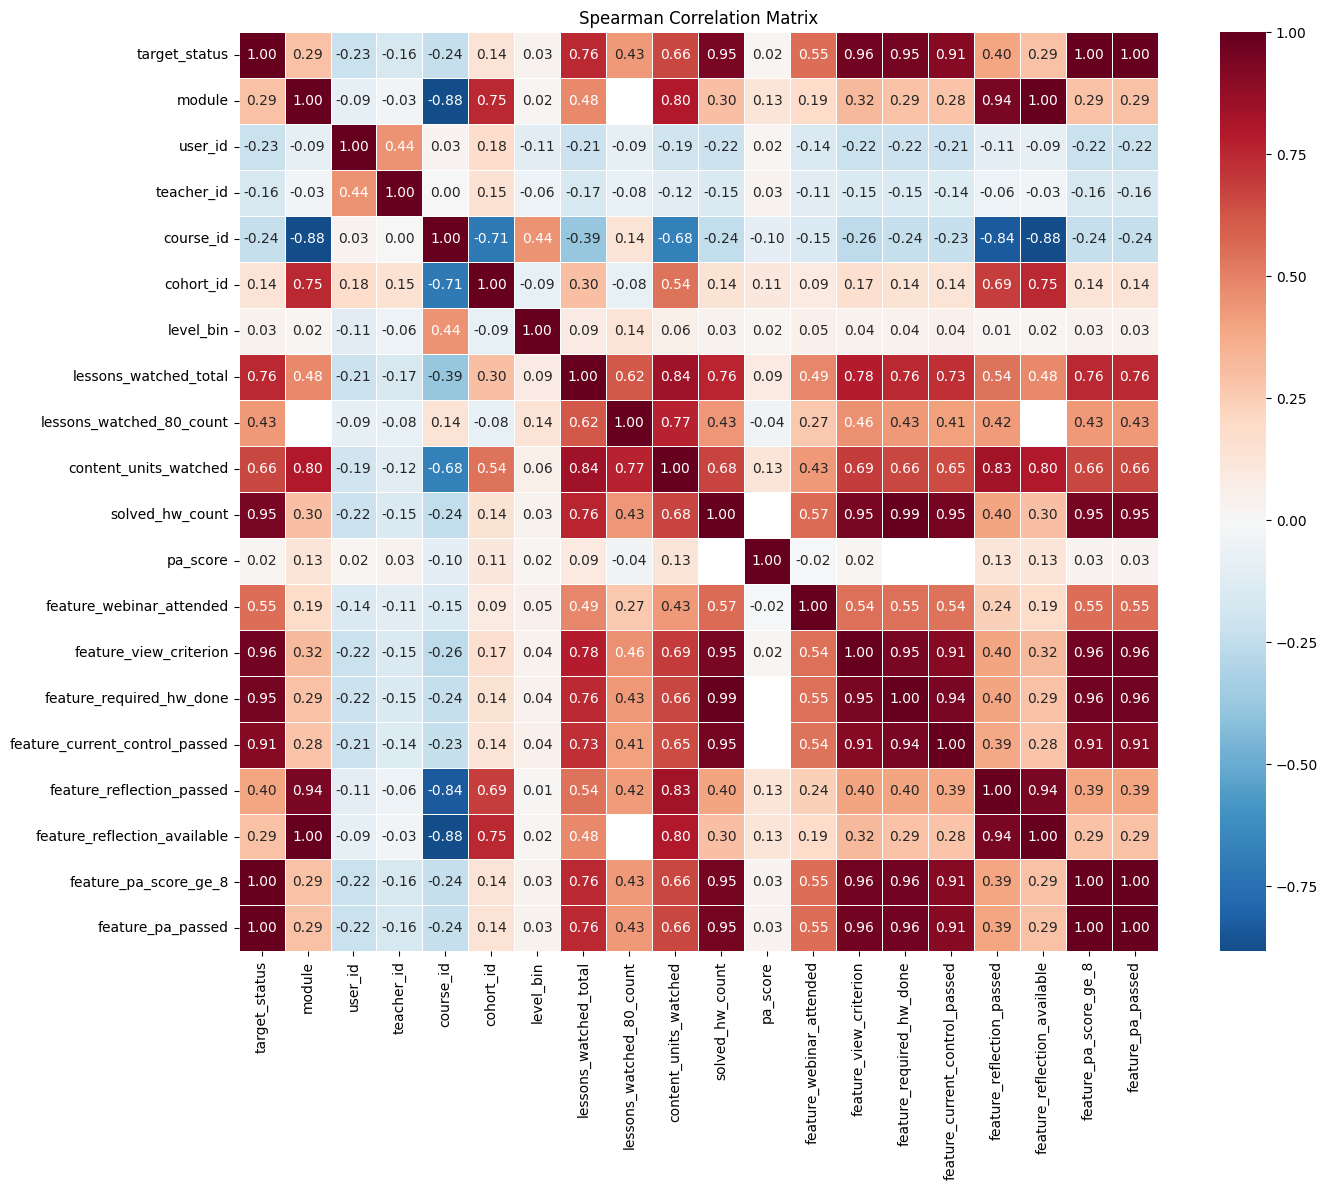

In [155]:
plt.figure(figsize=(15, 12))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

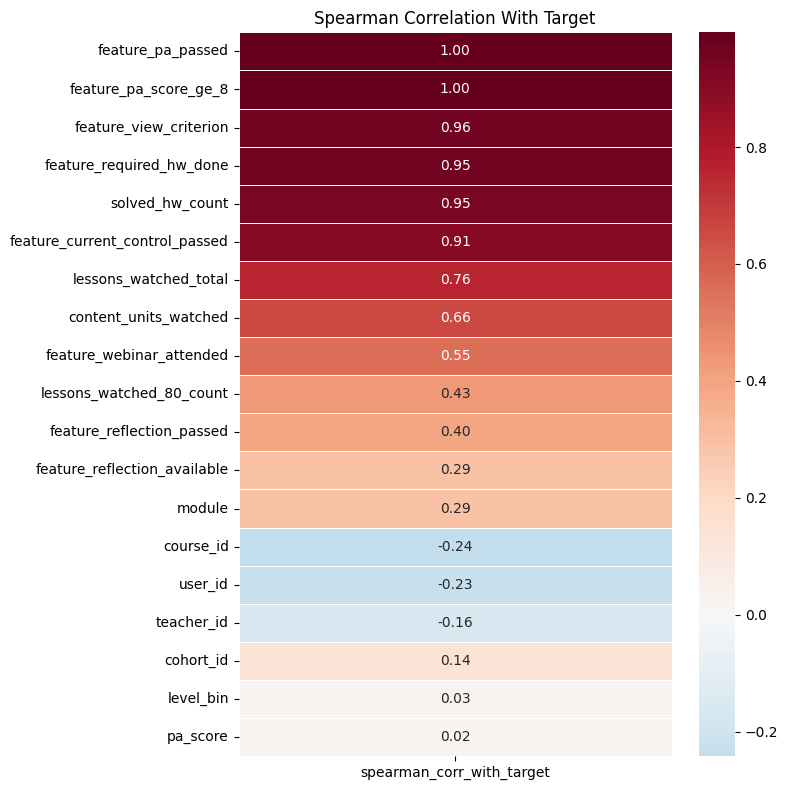

In [156]:
plt.figure(figsize=(8, 8))
sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
)
plt.title("Spearman Correlation With Target")
plt.tight_layout()
plt.show()

## 9. Финальный единый датасет

Это итоговый unified dataset на уровне `module + user_id + course_id` по всем 4 модулям.

Для `module 4`:

- строки входят в общий датасет;
- признаки стандартизированы так же, как для остальных модулей;
- `status_by_doc_heuristic` и `status_by_best_heuristic` оставлены пустыми.

In [157]:
display(user_course_df.head(5))

user_course_df.to_csv("status_modules_complete.csv")

,module,user_id,club_name,teacher_id,course_id,cohort_id,level_bin,enrollment_date,lessons_watched_total,lessons_watched_80_count,content_units_watched,view_criterion,webinar_attended,solved_hw_count,required_hw_done,current_control_passed,reflection_passed,pa_score,pa_passed,pa_date_msk,ia_passed,status_actual,feature_webinar_attended,feature_view_criterion,feature_required_hw_done,feature_current_control_passed,feature_reflection_passed,feature_reflection_available,feature_pa_score_ge_8,feature_pa_passed,status_by_doc_heuristic,status_by_best_heuristic
0,1,701741.0,Python. Начальный уровень. Онлайн. 1 модуль,699869.0,1029.0,1149.0,0,2025-09-19,20,<NA>,100.000000,1,0,60,1,1,<NA>,15.0,1,2025-12-05,<NA>,Завершил,0,1,1,1,0,0,1,1,Dropped,Completed
1,1,737977.0,Python. Начальный уровень. Онлайн. 1 модуль,730341.0,1029.0,1216.0,0,2025-11-05,20,<NA>,97.915459,1,1,60,1,1,<NA>,14.0,1,2025-11-29,<NA>,Завершил,1,1,1,1,0,0,1,1,Completed,Completed
2,1,722851.0,Python. Базовый уровень. Онлайн. 1 модуль,730208.0,1030.0,1186.0,1,2025-10-21,0,<NA>,0.000000,0,0,0,0,0,<NA>,NaN,0,NaN,<NA>,Отчислен,0,0,0,0,0,0,0,0,Dropped,Dropped
3,1,709724.0,Python. Базовый уровень. Онлайн. 1 модуль,700089.0,1030.0,1108.0,1,2025-09-23,20,<NA>,99.160018,1,1,60,1,1,<NA>,14.0,1,2025-11-28,<NA>,Завершил,1,1,1,1,0,0,1,1,Completed,Completed
4,1,717763.0,Python. Базовый уровень. Онлайн. 1 модуль,718519.0,1030.0,1055.0,1,2025-10-09,0,<NA>,0.000000,0,0,0,0,0,<NA>,NaN,0,NaN,<NA>,Отчислен,0,0,0,0,0,0,0,0,Dropped,Dropped
